In [19]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
import sympy as sp
from sympy import lambdify 
from sympy.abc import x, y, s


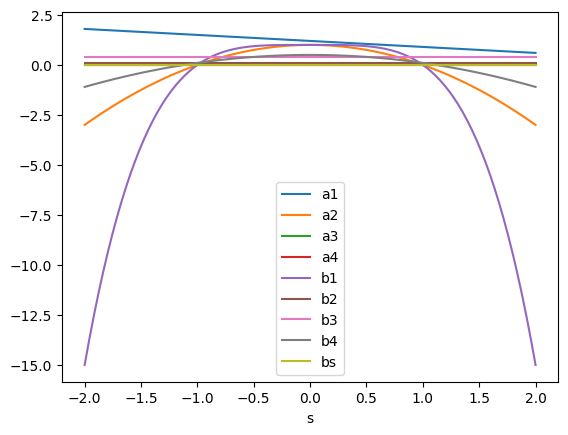

In [20]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = ["1.2-0.3*s", "1-s**2", 0.02, 0.002]
b_coeffs = ["1-s**4",0.1,0.4, "0.5-0.4*s**2"]
# a_coeffs = ["3.4/(exp(s)+exp(-s))","-0.5*s**2+1.2",0.3,0.5]
# b_coeffs = ["2*exp(-s**2)",0.5,"1/(1+s**2)**1.5",0.05]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs, nphi=6)
expansion.plot_components()
plt.xlabel('s')
plt.show()

Scalar potential phi(x,y,s): -8.33333333333333e-5*x**4 - 0.00333333333333333*x**3 - x**2*(1 - s**2)/2 - x*(1.2 - 0.3*s) - y**5*(-9.6*x - 144)/720 + 0.166583333333333*y**4 + y**3*(-72*s**2 - 0.8*x**3 + 6*x*(0.5 - 0.4*s**2) + 2.4)/36 + y**2*(-24*s**2 - 23.976*x**2 + 0.48*x + 24)/48 - y*(-6*s**4 + x**3*(0.5 - 0.4*s**2) + 1.2*x**2 + 0.6*x + 6)/6
Scalar potential phi at (0.4,0.2,0.5): -0.6739380711111111


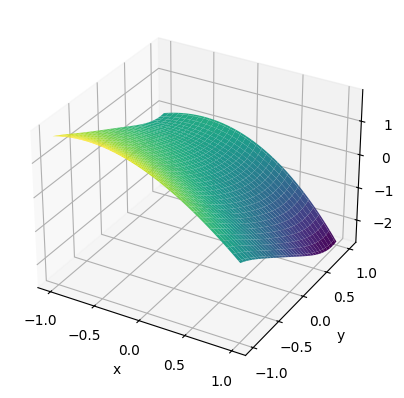

In [21]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-0.5,0.5,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.2)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [22]:
#B=expansion.create_fieldmap(xarr=xa,yarr=ya,sarr=sa, filename=None)
#B.plot()

In [23]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func) with lamdify = False
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)

Ax: <numpy.vectorize object at 0x7f0ed6388dd0> Ay: <numpy.vectorize object at 0x7f0ed6782b10> As: <numpy.vectorize object at 0x7f0ec7f72240>


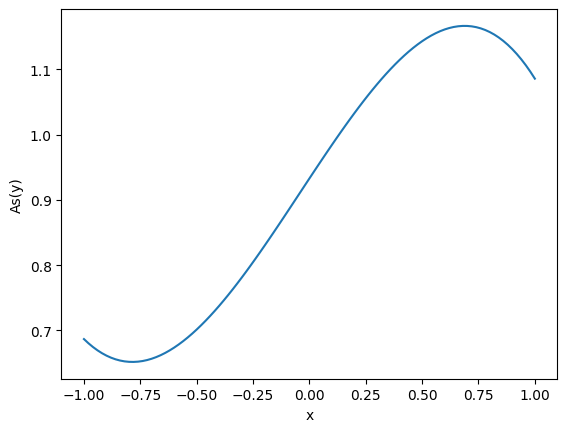

In [24]:
Ax, Ay, As = expansion.get_A(lambdify=True)
print("Ax:", Ax, "Ay:", Ay, "As:", As)
Ax_ana = Ax(X, Y, S)
Ay_ana = Ay(X, Y, S)
As_ana = As(X, Y, S)

#plot As as a function of 
plt.plot(xa, As_ana[2, :, 10])
plt.ylabel('As(y)')
plt.xlabel('x')
plt.show()

Max difference in Bx: 0.02600561323732986
Max difference in By: 0.034633333333327965
Max difference in Bs: 0.06544413333333132


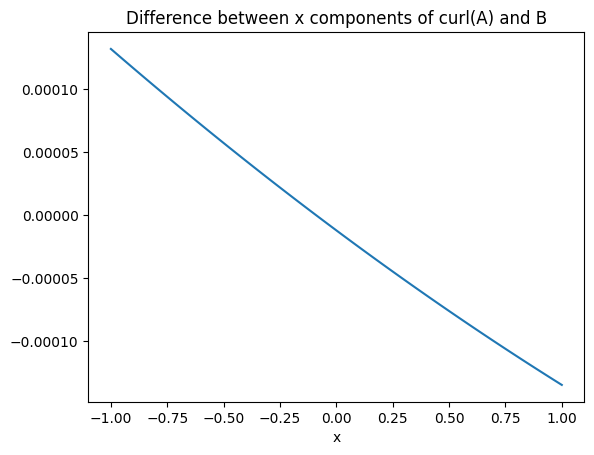

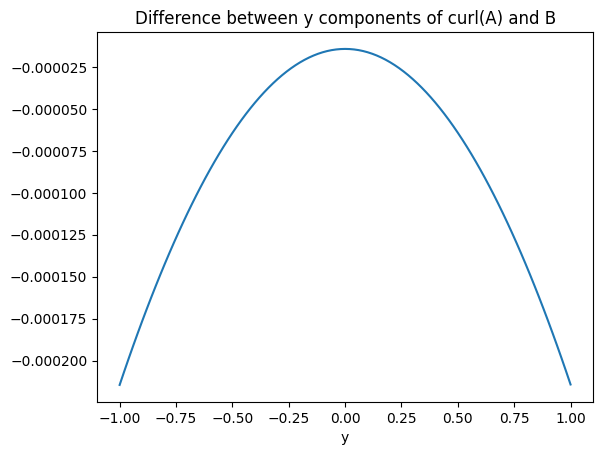

In [25]:
#then take the curl of A from finite differences and compare with the original B field
def curl_3d(Ax, Ay, Az, dx, dy, dz):
  
    # Compute partial derivatives
    dAx_dy = np.gradient(Ax, dy, axis=1)
    dAx_dz = np.gradient(Ax, dz, axis=2)
    dAy_dx = np.gradient(Ay, dx, axis=0)
    dAy_dz = np.gradient(Ay, dz, axis=2)
    dAz_dx = np.gradient(Az, dx, axis=0)
    dAz_dy = np.gradient(Az, dy, axis=1)
    
    # Curl components
    curl_x = dAz_dy - dAy_dz
    curl_y = dAx_dz - dAz_dx
    curl_z = dAy_dx - dAx_dy
    
    return curl_x, curl_y, curl_z

# Compute spacings
dx = xa[1] - xa[0]
dy = ya[1] - ya[0]
ds = sa[1] - sa[0]
# Compute curl
curl_Ax, curl_Ay, curl_As = curl_3d(Ax_ana, Ay_ana, As_ana, dx, dy, ds)

# Compare B from bpmeth with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_Ax - Bx_ana)))
print("Max difference in By:", np.max(np.abs(curl_Ay - By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_As - Bs_ana)))

plt.plot(xa, Bx_ana[:,30,20]-curl_Ax[:,30,20])
plt.xlabel('x')
plt.title("Difference between x components of curl(A) and B")
plt.show()
plt.plot(ya, By_ana[30,:,20]-curl_Ay[30,:,20])
plt.xlabel('y')
plt.title("Difference between y components of curl(A) and B")
plt.show()

Now we can go back to the multipole components using 

$a_{n}(s) = \left. \partial^{n-1}_x B_x(x,y,s) \right|_{x=y=0}$

and

$ b_{n}(s) = \left. \partial^{n-1}_x B_y(x,y,s) \right|_{x=y=0} $

In [26]:
def derivativesFromField(x, B_i, max_order): #i= x or y, B_i is the 3d array of the field component evaluated on the grid, max_order is the maximum order of derivative to compute
    dBvector=np.zeros((max_order+1, len(B_i),len(sa)))
    dBvector[0,:,:] = B_i[:, B_i.shape[1]//2, :] #take the field at y=0, keep x,s dependence
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector
max_order = 4
idx_zero = np.argmin(np.abs(xa))

dBxvector=derivativesFromField(xa, curl_Ax, max_order)
dByvector=derivativesFromField(xa, curl_Ay, max_order)

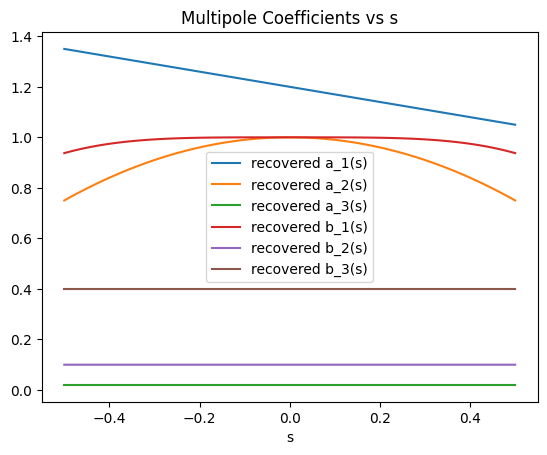

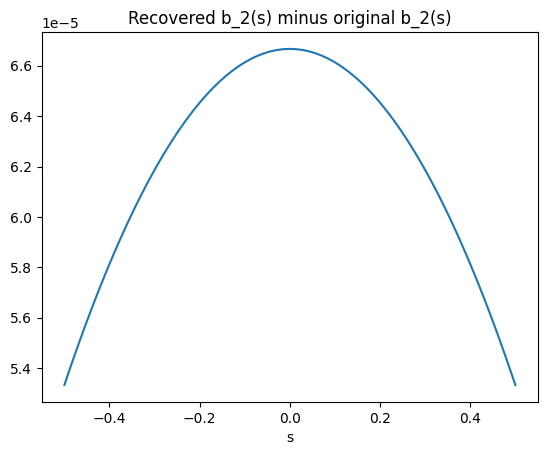

In [27]:
a_nnew=np.zeros((len(a_coeffs),len(sa)))
b_nnew=np.zeros((len(b_coeffs),len(sa)))
a_nnew[:,:]=dBxvector[:max_order,idx_zero,:]
b_nnew[:,:]=dByvector[:max_order,idx_zero,:]

plt.plot(sa, a_nnew[0,:], label='recovered a_1(s)')
plt.plot(sa, a_nnew[1,:], label='recovered a_2(s)')
plt.plot(sa, a_nnew[2,:], label='recovered a_3(s)')
plt.plot(sa, b_nnew[0,:], label='recovered b_1(s)')
plt.plot(sa, b_nnew[1,:], label='recovered b_2(s)')
plt.plot(sa, b_nnew[2,:], label='recovered b_3(s)')
plt.xlabel('s')
plt.legend()
plt.title('Multipole Coefficients vs s')
plt.show()

original_b_ana = lambdify(XYS, b_coeffs, 'numpy')
plt.plot(sa, b_nnew[1,:]-original_b_ana(0,0,sa)[1], label='recovered b_2(s)')
plt.xlabel('s')
plt.title('Recovered b_2(s) minus original b_2(s)')
plt.show()


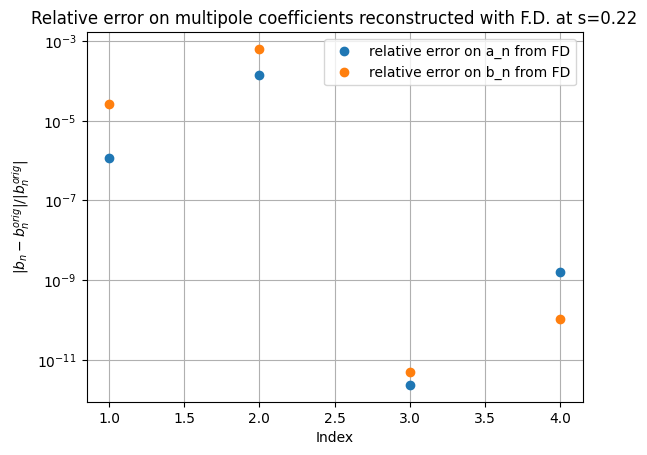

In [31]:
p=4#how many values to plot
#evaluate the symbolic expressions of the original coefficients to compare them with the recovered ones
b_ana = lambdify(s, b_coeffs, 'numpy')
a_ana = lambdify(s, a_coeffs, 'numpy')
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_ana(0.22)[:p]-a_nnew[:p,72])/a_ana(0.22)[:p], 'o', label='relative error on a_n from FD')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_ana(0.22)[:p]-b_nnew[:p,72])/b_ana(0.22)[:p], 'o', label='relative error on b_n from FD')
plt.yscale('log')
plt.xlabel('Index')
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.title('Relative error on multipole coefficients reconstructed with F.D. at s=0.22')
plt.legend()
plt.grid(True)
plt.show()

In [116]:
print(np.abs(a_ana(0.5)[0]-a_nnew[0,int(len(sa)/2)])/a_ana(0.5)[0])

1.2698412698072946e-06


Now reconstruct a field from the recovered components. The expansion method wants symbolic expressions as coefficients, so we must fit.

In [117]:
# degree=3
# coeffs = np.polyfit(sa, 1.3+sa, deg=degree)
# poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
# poly_expr = sp.expand(poly_expr)
# print(poly_expr)


fit on reconstruction ['-6.38566246773627e-14*s**5 + 1.42015319512065e-13*s**4 - 1.05319393559213e-13*s**3 + 2.71706297964293e-14*s**2 - 0.300000000000001*s + 1.19999866666667', '-4.6339421076801e-13*s**5 + 9.71241467250175e-13*s**4 - 7.29433829915674e-13*s**3 - 0.999999999999732*s**2 - 5.19810867919946e-14*s + 1.00013333333333', '4.94274539336317e-12*s**5 - 2.16116087584615e-11*s**4 + 3.1065374220676e-11*s**3 - 1.82600980448328e-11*s**2 + 4.07189831237495e-12*s + 0.0199999999997753', '1.17266010954166e-9*s**5 - 2.57320209828725e-9*s**4 + 2.03278832377798e-9*s**3 - 7.56118668606005e-10*s**2 + 1.38237099318413e-10*s + 0.0019999999966374']
original ['1.2-0.3*s', '1-s**2', 0.02, 0.002]


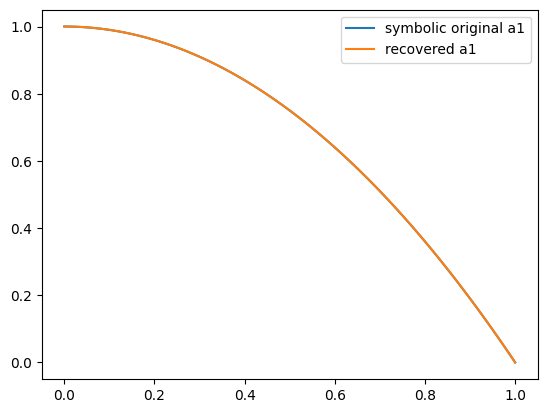

In [151]:
degree = 5

b_nfit = []

for j in range(b_nnew.shape[0]):
    coeffs = np.polyfit(sa, b_nnew[j, :], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    b_nfit.append(str(poly_expr))

a_nfit=[]

for j in range(a_nnew.shape[0]):
    coeffs = np.polyfit(sa, a_nnew[j, :], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    a_nfit.append(str(poly_expr))

print("fit on reconstruction", a_nfit)
print("original",a_coeffs)
plt.plot(sa, 1-sa**2, label="symbolic original a1")
plt.plot(sa, a_nnew[1,:], label='recovered a1')

plt.legend()


/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:129: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


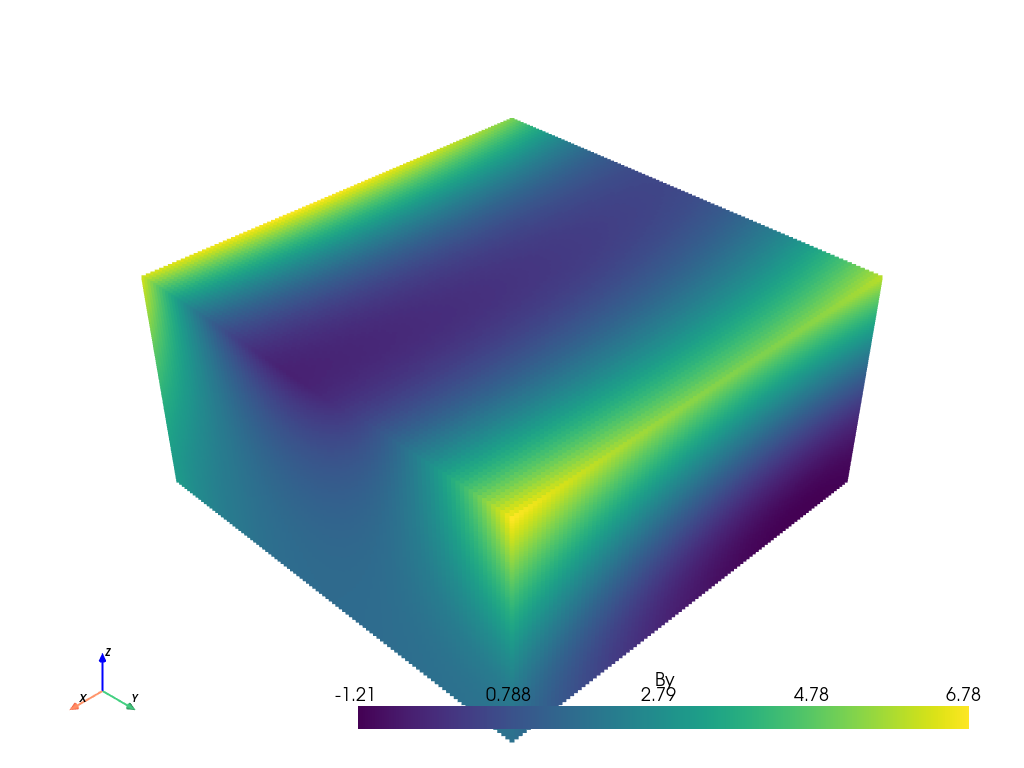

In [152]:
reconstruction=bpmeth.FieldExpansion(a=a_nfit, b=b_nfit)
#make a fieldmap of this reconstruction
Bx_rec, By_rec, Bs_rec = reconstruction.get_Bfield(lambdify=True)
Bx_rec_mesh = Bx_rec(X, Y, S)
By_rec_mesh = By_rec(X, Y, S)
Bs_rec_mesh = Bs_rec(X, Y, S)
reconfieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_rec_mesh.ravel(),
    By_rec_mesh.ravel(),
    Bs_rec_mesh.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm_rec = bpmeth.fieldmaps.Fieldmap(reconfieldmap)
fm_rec.plot()


/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:129: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


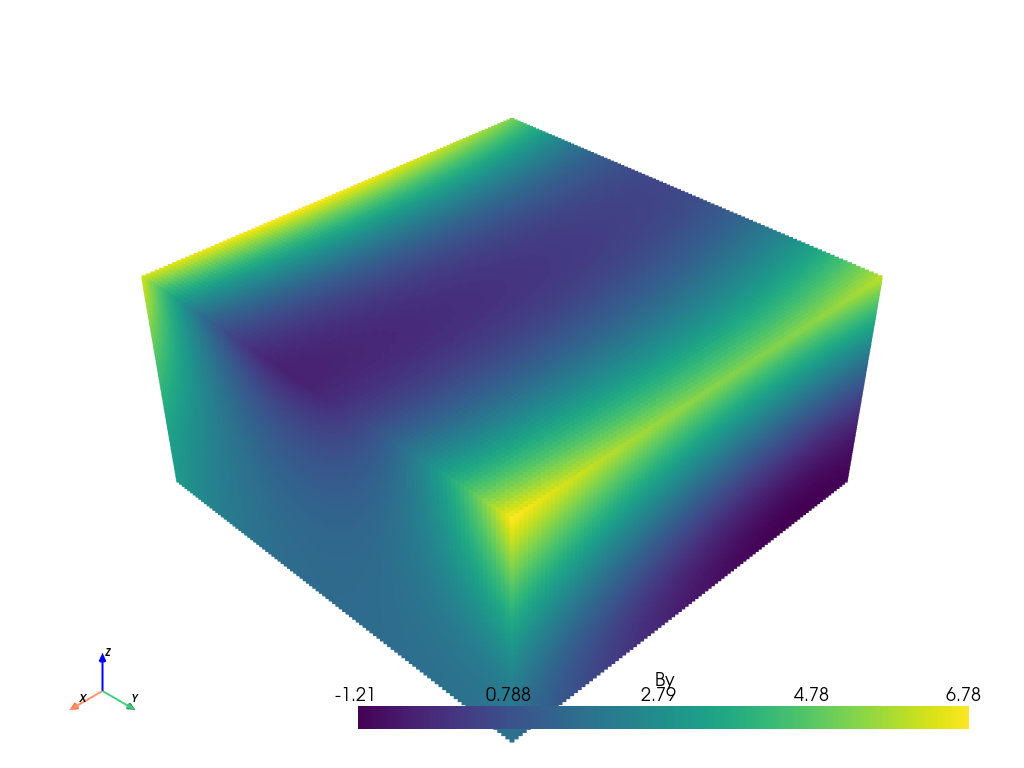

In [153]:
#make a fieldmap from the original expansion
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
fm.plot()

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:129: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


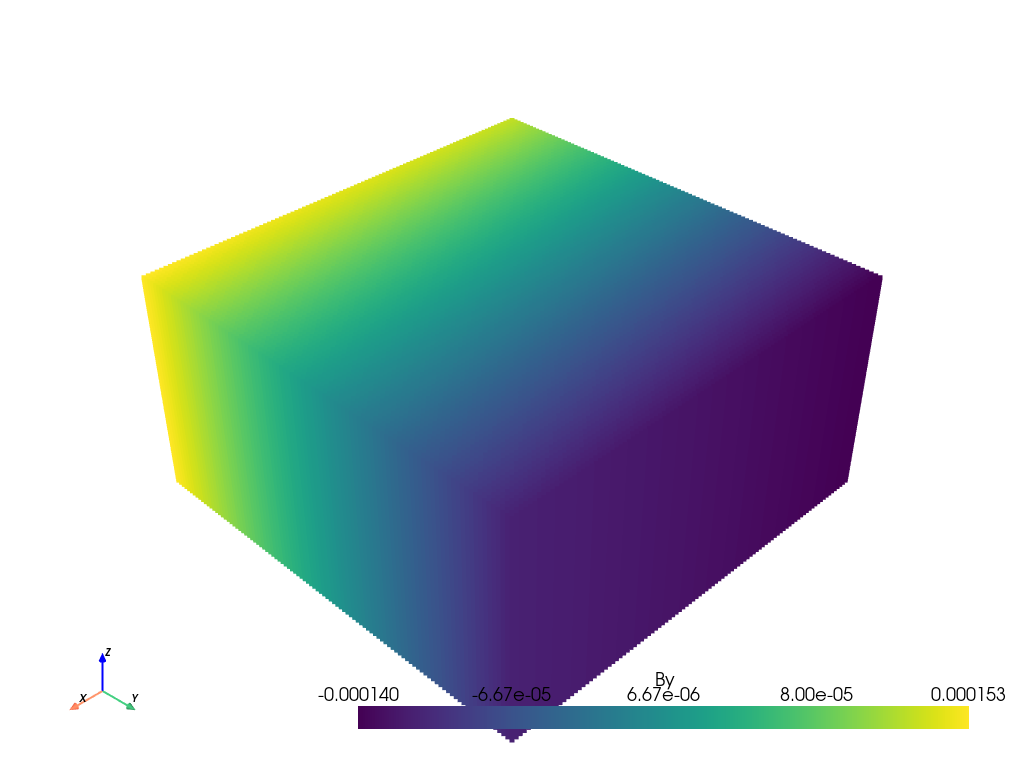

In [154]:
#make a fieldmap of the difference between the reconstruction and the original
resx=Bx_rec_mesh-Bx_ana
resy=By_rec_mesh-By_ana
ress=Bs_rec_mesh-Bs_ana
residualfieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    resx.ravel(),
    resy.ravel(),
    ress.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fmresidual = bpmeth.fieldmaps.Fieldmap(residualfieldmap)
fmresidual.plot()

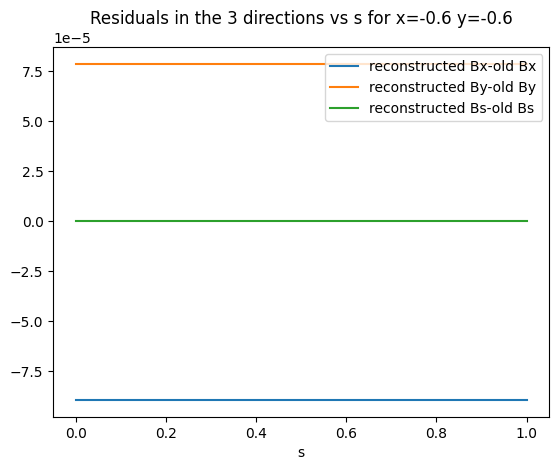

In [155]:
plt.plot(sa, resx[20,20,:],label='reconstructed Bx-old Bx')
plt.plot(sa, resy[20,20,:],label='reconstructed By-old By')
plt.plot(sa, ress[20,20,:],label='reconstructed Bs-old Bs')
plt.legend()
plt.title("Residuals in the 3 directions vs s for x="+ str(xa[20])+" y="+str(ya[20]))
plt.xlabel('s')
plt.show()

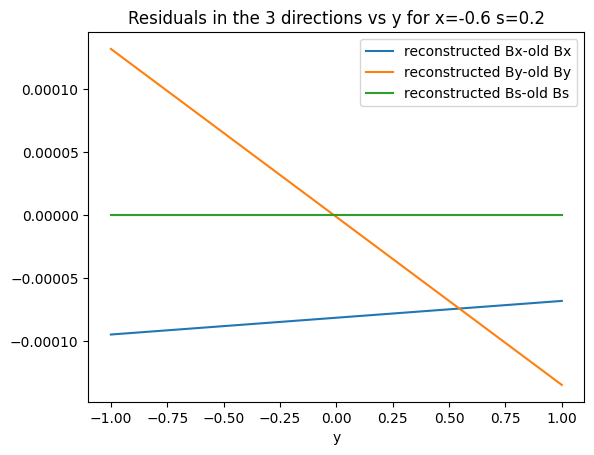

In [156]:
plt.plot(ya, resx[20,:,20],label='reconstructed Bx-old Bx')
plt.plot(ya, resy[20,:,20],label='reconstructed By-old By')
plt.plot(ya, ress[20,:,20],label='reconstructed Bs-old Bs')
plt.legend()
plt.title("Residuals in the 3 directions vs y for x="+ str(xa[20])+" s="+str(sa[20]))
plt.xlabel('y')
plt.show()

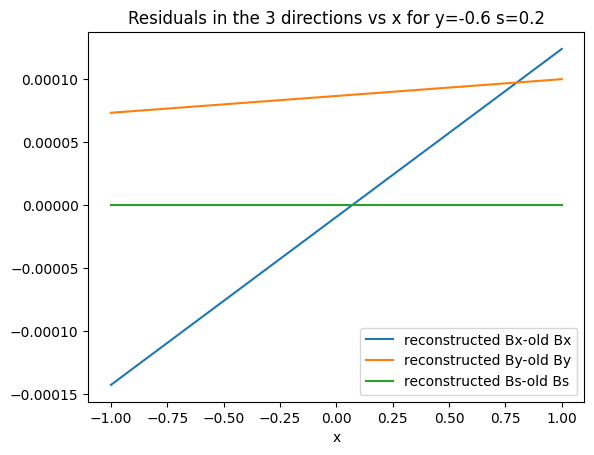

In [157]:
plt.plot(xa, resx[:,20,20],label='reconstructed Bx-old Bx')
plt.plot(xa, resy[:,20,20],label='reconstructed By-old By')
plt.plot(xa, ress[:,20,20],label='reconstructed Bs-old Bs')
plt.legend()
plt.title("Residuals in the 3 directions vs x for y="+ str(ya[20])+" s="+str(sa[20]))
plt.xlabel('x')
plt.show()